In [1]:
suppressPackageStartupMessages({
    library(tidyverse)
    library(data.table)
    library(Matrix)
    library(Seurat)
    library(R.utils)
    library(qs)
})

Warning message:
"package 'ggplot2' was built under R version 4.4.2"
Warning message:
"package 'tibble' was built under R version 4.4.2"
Warning message:
"package 'tidyr' was built under R version 4.4.2"
Warning message:
"package 'dplyr' was built under R version 4.4.2"
Warning message:
"package 'data.table' was built under R version 4.4.2"
Warning message:
"package 'qs' was built under R version 4.4.2"


# Data

In [2]:
seu <- qread("../Data/v2/seu_integrated.qs")

RNA dataset

In [3]:
seu_RNA_data <- qread("../Data/v2/seu_integrated_RNA_data.qs")

In [4]:
seu[["RNA"]]  <- seu_RNA_data

In [5]:
DefaultAssay(seu) <- "RNA"

## Visualize the Dataset

In [6]:
seu_plot <- UMAPPlot(seu) + scale_x_reverse()

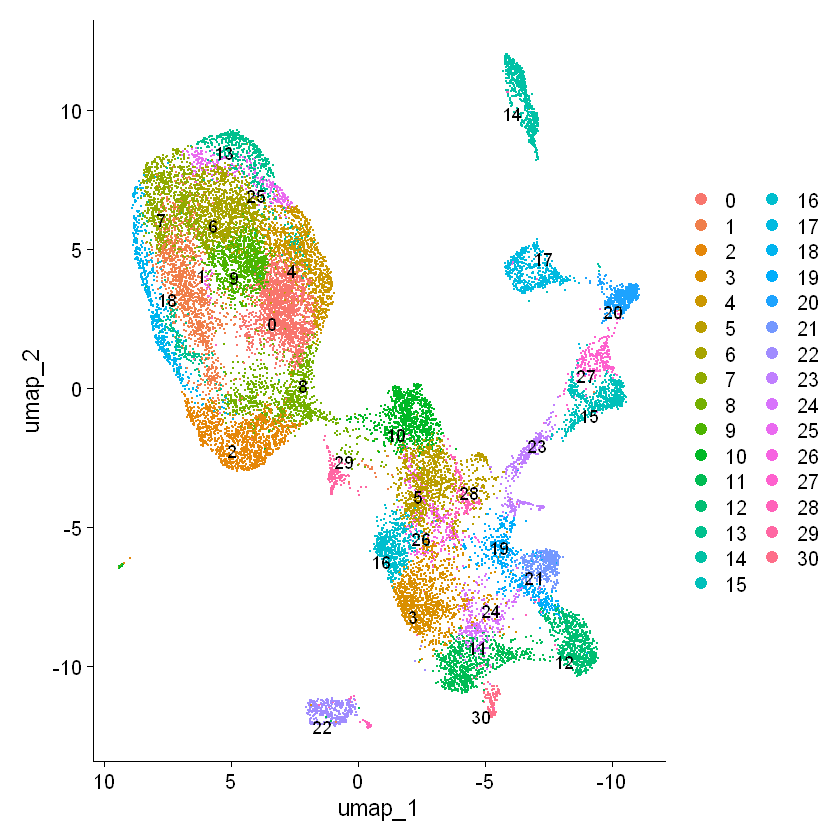

In [7]:
LabelClusters(plot = seu_plot, id = "ident")

## Explore the data

In [8]:
length(Features(seu))

[1] 36601

In [9]:
dim(seu)

[1] 36601 22446

In [10]:
head(seu)

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,pool,barcode,CD34_subpool,CD34,nCount_HTO,nFeature_HTO,⋯,seurat_clusters_resolution_0.9,seurat_clusters_resolution_1,seurat_clusters_resolution_1.1,seurat_clusters_resolution_1.2,seurat_clusters_resolution_1.3,seurat_clusters_resolution_1.4,seurat_clusters_resolution_1.5,seurat_post_scn_clusters,seurat_post_scn_lineages,RNA_snn_res.1.5
,<chr>,<dbl>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>
A_A_AAACGCTTCACTTGTT_A_pos_A_pos,SeuratProject,29477,6684,2.337416,A,AAACGCTTCACTTGTT_A_pos_A_pos,pos,pos,12.95035,7,⋯,1,2,2,10,9,4,4,G-prog-2,G-prog,3
A_A_AAAGGATCAATGCAGG_A_pos_A_pos,SeuratProject,43334,7226,5.169151,A,AAAGGATCAATGCAGG_A_pos_A_pos,pos,pos,15.05035,7,⋯,6,9,6,4,10,2,8,E-prog-mid-1,E-prog-mid,1
A_A_AAAGGATGTGCGAGTA_A_pos_A_pos,SeuratProject,46221,7362,4.013327,A,AAAGGATGTGCGAGTA_A_pos_A_pos,pos,pos,15.08825,7,⋯,1,2,2,16,14,4,19,G-prog-1,G-prog,3
A_A_AAAGGATTCACTGATG_A_pos_A_pos,SeuratProject,25484,4623,7.243761,A,AAAGGATTCACTGATG_A_pos_A_pos,pos,pos,15.45288,7,⋯,6,5,12,4,11,3,6,Mk-prog-1(MEP?),Mk-prog,8
A_A_AAAGGGCCACCCTCTA_A_pos_A_pos,SeuratProject,28699,6420,2.871180,A,AAAGGGCCACCCTCTA_A_pos_A_pos,pos,pos,13.39873,7,⋯,12,12,17,9,23,24,23,"Pro-B-1(Very Early, Ly-Prog?)",Pro-B,23
A_A_AAAGGTAGTCGCATCG_A_pos_A_pos,SeuratProject,20363,4041,4.262633,A,AAAGGTAGTCGCATCG_A_pos_A_pos,pos,pos,13.94815,7,⋯,3,7,5,7,3,8,5,MPP-1,MPP,28
A_A_AAAGGTATCATTGTGG_A_pos_A_pos,SeuratProject,31372,6826,6.802244,A,AAAGGTATCATTGTGG_A_pos_A_pos,pos,pos,14.06702,7,⋯,1,2,2,16,14,17,19,G-prog-1,G-prog,16
A_A_AAAGGTATCCGAGGCT_A_pos_A_pos,SeuratProject,31802,5299,6.716559,A,AAAGGTATCCGAGGCT_A_pos_A_pos,pos,pos,13.56343,7,⋯,20,21,7,12,7,26,12,E-prog-mid-3,E-prog-mid,25
A_A_AAAGGTATCGGTCACG_A_pos_A_pos,SeuratProject,48519,7748,6.618026,A,AAAGGTATCGGTCACG_A_pos_A_pos,pos,pos,13.91931,7,⋯,0,0,8,8,7,7,7,E-prog-early-2,E-prog-early,0


In [11]:
rownames(seu)

[1] "MIR1302-2HG"       "FAM138A"           "OR4F5"            
    [4] "AL627309.1"        "AL627309.3"        "AL627309.2"       
    [7] "AL627309.5"        "AL627309.4"        "AP006222.2"       
   [10] "AL732372.1"        "OR4F29"            "AC114498.1"       
   [13] "OR4F16"            "AL669831.2"        "LINC01409"        
   [16] "FAM87B"            "LINC01128"         "LINC00115"        
   [19] "FAM41C"            "AL645608.6"        "AL645608.2"       
   [22] "AL645608.4"        "LINC02593"         "SAMD11"           
   [25] "NOC2L"             "KLHL17"            "PLEKHN1"          
   [28] "PERM1"             "AL645608.7"        "HES4"             
   [31] "ISG15"             "AL645608.1"        "AGRN"             
   [34] "AL645608.5"        "AL645608.8"        "RNF223"           
   [37] "C1orf159"          "AL390719.3"        "LINC01342"        
   [40] "AL390719.2"        "TTLL10-AS1"        "TTLL10"           
   [43] "TNFRSF18"          "TNFRSF4"           "SDF4"             
   [46] "B3GALT6"           "C1QTNF12"          "AL162741.1"       
   [49] "UBE2J2"            "LINC01786"         "SCNN1D"           
   [52] "ACAP3"             "PUSL1"             "INTS11"           
   [55] "AL139287.1"        "CPTP"              "TAS1R3"           
   [58] "DVL1"              "MXRA8"             "AURKAIP1"         
   [61] "CCNL2"             "MRPL20-AS1"        "MRPL20"           
   [64] "AL391244.2"        "ANKRD65"           "AL391244.1"       
   [67] "TMEM88B"           "LINC01770"         "VWA1"             
   [70] "ATAD3C"            "ATAD3B"            "ATAD3A"           
   [73] "TMEM240"           "SSU72"             "AL645728.1"       
   [76] "FNDC10"            "AL691432.4"        "AL691432.2"       
   [79] "MIB2"              "MMP23B"            "CDK11B"           
   [82] "FO704657.1"        "SLC35E2B"          "CDK11A"           
   [85] "SLC35E2A"          "NADK"              "GNB1"             
   [88] "AL109917.1"        "CALML6"            "TMEM52"           
   [91] "CFAP74"            "AL391845.2"        "GABRD"            
   [94] "AL391845.1"        "PRKCZ"             "AL590822.2"       
   [97] "PRKCZ-AS1"         "FAAP20"            "AL590822.1"       
  [100] "SKI"               "AL590822.3"        "MORN1"            
  [103] "AL589739.1"        "AL513477.2"        "RER1"             
  [106] "PEX10"             "PLCH2"             "AL139246.1"       
  [109] "AL139246.4"        "PANK4"             "HES5"             
  [112] "AL139246.5"        "TNFRSF14-AS1"      "TNFRSF14"         
  [115] "AL139246.3"        "PRXL2B"            "MMEL1"            
  [118] "AL831784.1"        "TTC34"             "AC242022.2"       
  [121] "AC242022.1"        "AL592464.2"        "AL592464.3"       
  [124] "AL592464.1"        "AL589702.1"        "ACTRT2"           
  [127] "PRDM16-DT"         "PRDM16"            "AL008733.1"       
  [130] "AL590438.1"        "AL354743.2"        "AL354743.1"       
  [133] "ARHGEF16"          "AL512413.1"        "MEGF6"            
  [136] "AL513320.1"        "TPRG1L"            "WRAP73"           
  [139] "TP73"              "AL136528.1"        "AL136528.2"       
  [142] "CCDC27"            "SMIM1"             "LRRC47"           
  [145] "AL365330.1"        "CEP104"            "DFFB"             
  [148] "C1orf174"          "LINC01134"         "LINC01346"        
  [151] "LINC01345"         "LINC02780"         "AL805961.1"       
  [154] "LINC01777"         "AL355602.1"        "Z98747.1"         
  [157] "LINC01646"         "AJAP1"             "Z98886.1"         
  [160] "BX005132.1"        "LINC02781"         "LINC02782"        
  [163] "AL139823.1"        "Z98259.3"          "Z98259.2"         
  [166] "Z98259.1"          "AL365255.1"        "NPHP4"            
  [169] "KCNAB2"            "CHD5"              "RPL22"            
  [172] "AL031847.1"        "RNF207"            "ICMT"             
  [175] "LINC00337"         "HES3"              "GPR153"    

In [12]:
colnames(seu)

[1] "A_A_AAACGCTTCACTTGTT_A_pos_A_pos"  "A_A_AAAGGATCAATGCAGG_A_pos_A_pos" 
    [3] "A_A_AAAGGATGTGCGAGTA_A_pos_A_pos"  "A_A_AAAGGATTCACTGATG_A_pos_A_pos" 
    [5] "A_A_AAAGGGCCACCCTCTA_A_pos_A_pos"  "A_A_AAAGGTAGTCGCATCG_A_pos_A_pos" 
    [7] "A_A_AAAGGTATCATTGTGG_A_pos_A_pos"  "A_A_AAAGGTATCCGAGGCT_A_pos_A_pos" 
    [9] "A_A_AAAGGTATCGGTCACG_A_pos_A_pos"  "A_A_AAAGGTATCTCGCAGG_A_pos_A_pos" 
   [11] "A_A_AAAGTGACAAAGTATG_A_pos_A_pos"  "A_A_AACAAAGAGGGCCCTT_A_pos_A_pos" 
   [13] "A_A_AACAAAGGTGCTCTTC_A_pos_A_pos"  "A_A_AACAAAGTCTGCATAG_A_pos_A_pos" 
   [15] "A_A_AACACACAGCAAACAT_A_pos_A_pos"  "A_A_AACACACAGCGAGGAG_A_pos_A_pos" 
   [17] "A_A_AACACACTCTCAATCT_A_pos_A_pos"  "A_A_AACCAACCAGAACCGA_A_pos_A_pos" 
   [19] "A_A_AACCACAAGTCAACAA_A_pos_A_pos"  "A_A_AACCACATCCATTGTT_A_pos_A_pos" 
   [21] "A_A_AACCATGCAGTTCTAG_A_pos_A_pos"  "A_A_AACCTGATCAAACGAA_A_pos_A_pos" 
   [23] "A_A_AACGAAAAGTTGTCAC_A_pos_A_pos"  "A_A_AACGGGAGTTGCAAGG_A_pos_A_pos" 
   [25] "A_A_AACTTCTGTGTAAATG_A_pos_A_pos"  "A_A_AACTTCTTCAGTGGGA_A_pos_A_pos" 
   [27] "A_A_AACTTCTTCATGGAGG_A_pos_A_pos"  "A_A_AAGACAAGTCAACGCC_A_pos_A_pos" 
   [29] "A_A_AAGACTCGTGAATGAT_A_pos_A_pos"  "A_A_AAGATAGCAATGCAAA_A_pos_A_pos" 
   [31] "A_A_AAGATAGCACAGTCGC_A_pos_A_pos"  "A_A_AAGATAGCAGTCAGTT_A_pos_A_pos" 
   [33] "A_A_AAGATAGTCTCACGAA_A_pos_A_pos"  "A_A_AAGCATCAGGCCGCTT_A_pos_A_pos" 
   [35] "A_A_AAGCATCGTCATACCA_A_pos_A_pos"  "A_A_AAGCCATCAATCTGCA_A_pos_A_pos" 
   [37] "A_A_AAGCGTTAGTCCTGTA_A_pos_A_pos"  "A_A_AAGGAATCACCCTATC_A_pos_A_pos" 
   [39] "A_A_AAGGAATCATTGACAC_A_pos_A_pos"  "A_A_AAGGTAAGTTCAGGTT_A_pos_A_pos" 
   [41] "A_A_AAGTCGTCAGTGAGCA_A_pos_A_pos"  "A_A_AAGTGAAGTATGTGTC_A_pos_A_pos" 
   [43] "A_A_AAGTGAAGTGACGTCC_A_pos_A_pos"  "A_A_AAGTTCGAGTCGAAAT_A_pos_A_pos" 
   [45] "A_A_AATAGAGAGTACAGCG_A_pos_A_pos"  "A_A_AATCACGGTATGAAGT_A_pos_A_pos" 
   [47] "A_A_AATCGACCAACTGGTT_A_pos_A_pos"  "A_A_AATCGACCAATTGAAG_A_pos_A_pos" 
   [49] "A_A_AATCGTGAGGCTCTAT_A_pos_A_pos"  "A_A_AATCGTGGTAGTCGTT_A_pos_A_pos" 
   [51] "A_A_AATGAAGGTGAGCAGT_A_pos_A_pos"  "A_A_AATGACCGTCCTGTTC_A_pos_A_pos" 
   [53] "A_A_AATGCCACAACTCATG_A_pos_A_pos"  "A_A_AATGCCAGTCACCTTC_A_pos_A_pos" 
   [55] "A_A_AATGCCATCCCAAGCG_A_pos_A_pos"  "A_A_AATGGAACAGATGCGA_A_pos_A_pos" 
   [57] "A_A_AATGGAAGTAGACGGT_A_pos_A_pos"  "A_A_AATGGCTGTATCGTAC_A_pos_A_pos" 
   [59] "A_A_AATTTCCAGGGTATAT_A_pos_A_pos"  "A_A_AATTTCCGTACAGGTG_A_pos_A_pos" 
   [61] "A_A_ACAAAGACAAGTAGTA_A_pos_A_pos"  "A_A_ACAACCAAGTTGCCCG_A_pos_A_pos" 
   [63] "A_A_ACAACCACATGAATAG_A_pos_A_pos"  "A_A_ACAAGCTCATCGTGGC_A_pos_A_pos" 
   [65] "A_A_ACACAGTCAAATGCTC_A_pos_A_pos"  "A_A_ACACCAACAACTCGAT_A_pos_A_pos" 
   [67] "A_A_ACACCAAGTATCGTGT_A_pos_A_pos"  "A_A_ACACTGAAGTCCTGCG_A_pos_A_pos" 
   [69] "A_A_ACACTGAGTACCGTGC_A_pos_A_pos"  "A_A_ACAGCCGTCTAGTACG_A_pos_A_pos" 
   [71] "A_A_ACAGGGATCTGCGGGT_A_pos_A_pos"  "A_A_ACATCCCTCTCGTCAC_A_pos_A_pos" 
   [73] "A_A_ACATCGAGTATTGAGA_A_pos_A_pos"  "A_A_ACATCGAGTGAGTGAC_A_pos_A_pos" 
   [75] "A_A_ACATGCATCTCGACGG_A_pos_A_pos"  "A_A_ACATTTCTCATCCCGT_A_pos_A_pos" 
   [77] "A_A_ACCAAACAGGATATAC_A_pos_A_pos"  "A_A_ACCACAAGTGACCTGC_A_pos_A_pos" 
   [79] "A_A_ACCATTTTCGATAACC_A_pos_A_pos"  "A_A_ACCCAAACATCCTGTC_A_pos_A_pos" 
   [81] "A_A_ACCCTCAGTCTGCAAT_A_pos_A_pos"  "A_A_ACCCTTGCAATTTCCT_A_pos_A_pos" 
   [83] "A_A_ACCCTTGGTCAGTCTA_A_pos_A_pos"  "A_A_ACCTGAAAGCCTATCA_A_pos_A_pos" 
   [85] "A_A_ACCTGAATCAGAGTGG_A_pos_A_pos"  "A_A_ACCTGTCGTCGAGTGA_A_pos_A_pos" 
   [87] "A_A_ACCTGTCTCATGAGAA_A_pos_A_pos"  "A_A_ACCTGTCTCGGTAGAG_A_pos_A_pos" 
   [89] "A_A_ACGATCACACCATAAC_A_pos_A_pos"  "A_A_ACGATCATCGCTGTTC_A_pos_A_pos" 
   [91] "A_A_ACGATGTAGGGCATGT_A_pos_A_pos"  "A_A_ACGATGTTCATGTCAG_A_pos_A_pos" 
   [93] "A_A_ACGATGTTCCACCCTA_A_pos_A_pos"  "A_A_ACGCACGAGTCGGCCT_A_pos_A_pos" 
   [95] "A_A_ACGCACGGTAGCGCTC_A_pos_A_pos"  "A_A_ACGGAAGGTTGCAAGG_A_pos_A_pos" 
   [97] "A_A_ACGGGTCAGTCCTGTA_A_pos_A_pos"  "A_A_ACGGGTCCATCCAACA_A_pos_A_pos" 
   [99] "A_A_ACGGTTAGTTATAGAG_A_pos_A_pos"  "A_A_ACGTAACCATCCTATT_A_pos_A_pos" 
  [1

## Importing Nature Methods reference dataset

In [13]:
nature_spectra_path <- "../References/cNMF4.spectra.k_35.dt_0_15.consensus.txt"

In [14]:
spectra.t <- read.table(nature_spectra_path, header = TRUE, sep = "\t")
spectra.t

X,ABCA13,ABHD17B,ABHD8,ABLIM1,AC002480.5,AC002985.3,AC003664.1,AC004510.3,AC004691.5,⋯,ZNF720,ZNF726,ZNF76,ZNF770,ZNF790.AS1,ZNF792,ZNF829,ZNF98,ZRANB2,ZSCAN29
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,4.037138e-04,1.290061e-04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.561031e-05,⋯,3.200771e-04,0.000000e+00,1.795445e-04,2.639891e-05,0.000000e+00,0.000000e+00,3.220853e-04,0.000000e+00,3.323041e-04,1.046817e-03
2,1.626081e-03,1.903653e-04,5.273402e-04,6.913273e-04,4.248614e-04,1.121366e-04,2.541363e-04,3.616895e-04,2.634976e-04,⋯,8.402400e-04,1.331807e-03,1.071052e-03,5.805588e-04,4.699305e-04,4.034231e-04,8.789362e-04,7.264804e-04,5.293305e-04,8.734031e-04
3,4.665727e-08,1.557317e-04,0.000000e+00,8.398596e-04,3.834534e-04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,⋯,3.167402e-04,2.426609e-04,4.861702e-04,0.000000e+00,0.000000e+00,4.612713e-05,3.570141e-04,0.000000e+00,3.216228e-04,1.362637e-03
4,3.927303e-04,1.156419e-03,3.044580e-04,3.585300e-03,0.000000e+00,0.000000e+00,2.894145e-04,0.000000e+00,0.000000e+00,⋯,5.253167e-04,5.072930e-04,2.092257e-04,1.664867e-03,4.782508e-04,1.266647e-03,6.441579e-04,0.000000e+00,2.105280e-03,7.594478e-04
5,1.485559e-05,0.000000e+00,6.923341e-04,2.612954e-04,0.000000e+00,0.000000e+00,0.000000e+00,5.481140e-04,0.000000e+00,⋯,0.000000e+00,1.213477e-04,0.000000e+00,3.268598e-05,0.000000e+00,0.000000e+00,4.491670e-05,0.000000e+00,0.000000e+00,0.000000e+00
6,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.254937e-05,0.000000e+00,0.000000e+00,⋯,3.182447e-04,0.000000e+00,1.496780e-04,0.000000e+00,8.851968e-04,1.810611e-04,5.093236e-04,1.308876e-04,1.509837e-04,0.000000e+00
7,6.565215e-04,0.000000e+00,0.000000e+00,3.875568e-04,1.135598e-03,0.000000e+00,0.000000e+00,5.369790e-04,1.017732e-03,⋯,7.578034e-04,9.007138e-04,7.013929e-04,8.743214e-05,8.616086e-04,8.619480e-04,2.463427e-04,0.000000e+00,2.209803e-04,1.014350e-04
8,1.233864e-03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,7.096593e-04,0.000000e+00,⋯,0.000000e+00,1.490269e-03,0.000000e+00,2.679437e-04,6.120151e-04,6.869749e-05,1.956916e-04,0.000000e+00,1.165041e-03,1.698062e-05
9,4.239189e-06,0.000000e+00,1.606618e-04,2.035585e-04,5.098308e-04,2.671265e-04,2.714242e-05,3.574184e-04,0.000000e+00,⋯,0.000000e+00,3.563045e-04,4.717137e-05,3.107575e-04,2.348820e-04,7.746542e-04,1.970469e-04,1.803861e-04,5.928069e-05,1.671048e-04


# starCAT analysis

## Running starCAT (w gene intersection)

In [15]:
head(spectra.t)

,X,ABCA13,ABHD17B,ABHD8,ABLIM1,AC002480.5,AC002985.3,AC003664.1,AC004510.3,AC004691.5,⋯,ZNF720,ZNF726,ZNF76,ZNF770,ZNF790.AS1,ZNF792,ZNF829,ZNF98,ZRANB2,ZSCAN29
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,4.037138e-04,0.0001290061,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.000000e+00,0.0000000000,2.561031e-05,⋯,0.0003200771,0.0000000000,0.0001795445,2.639891e-05,0.0000000000,0.000000e+00,0.0003220853,0.0000000000,0.0003323041,0.0010468175
2,2,1.626081e-03,0.0001903653,0.0005273402,0.0006913273,0.0004248614,0.0001121366,2.541363e-04,0.0003616895,2.634976e-04,⋯,0.0008402400,0.0013318075,0.0010710524,5.805588e-04,0.0004699305,4.034231e-04,0.0008789362,0.0007264804,0.0005293305,0.0008734031
3,3,4.665727e-08,0.0001557317,0.0000000000,0.0008398596,0.0003834534,0.0000000000,0.000000e+00,0.0000000000,0.000000e+00,⋯,0.0003167402,0.0002426609,0.0004861702,0.000000e+00,0.0000000000,4.612713e-05,0.0003570141,0.0000000000,0.0003216228,0.0013626373
4,4,3.927303e-04,0.0011564193,0.0003044580,0.0035852997,0.0000000000,0.0000000000,2.894145e-04,0.0000000000,0.000000e+00,⋯,0.0005253167,0.0005072930,0.0002092257,1.664867e-03,0.0004782508,1.266647e-03,0.0006441579,0.0000000000,0.0021052803,0.0007594478
5,5,1.485559e-05,0.0000000000,0.0006923341,0.0002612954,0.0000000000,0.0000000000,0.000000e+00,0.0005481140,0.000000e+00,⋯,0.0000000000,0.0001213477,0.0000000000,3.268598e-05,0.0000000000,0.000000e+00,0.0000449167,0.0000000000,0.0000000000,0.0000000000
6,6,0.000000e+00,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,3.254937e-05,0.0000000000,0.000000e+00,⋯,0.0003182447,0.0000000000,0.0001496780,0.000000e+00,0.0008851968,1.810611e-04,0.0005093236,0.0001308876,0.0001509837,0.0000000000


In [16]:
dim(spectra.t)

[1]   35 2001

In [17]:
colnames(spectra.t)

[1] "X"               "ABCA13"          "ABHD17B"         "ABHD8"          
   [5] "ABLIM1"          "AC002480.5"      "AC002985.3"      "AC003664.1"     
   [9] "AC004510.3"      "AC004691.5"      "AC004869.3"      "AC005082.12"    
  [13] "AC005160.3"      "AC005618.6"      "AC005943.6"      "AC006116.12"    
  [17] "AC006486.10"     "AC006942.4"      "AC007091.1"      "AC007249.3"     
  [21] "AC007325.2"      "AC007557.1"      "AC008063.2"      "AC008073.7"     
  [25] "AC008079.9"      "AC008592.4"      "AC009133.21"     "AC009134.1"     
  [29] "AC009336.19"     "AC009506.1"      "AC010468.2"      "AC010731.3"     
  [33] "AC010761.6"      "AC010907.5"      "AC010974.3"      "AC012307.2"     
  [37] "AC013269.4"      "AC013463.2"      "AC015688.3"      "AC016991.1"     
  [41] "AC017074.1"      "AC018685.1"      "AC018816.3"      "AC020594.5"     
  [45] "AC034228.4"      "AC068831.3"      "AC073071.1"      "AC073316.1"     
  [49] "AC092625.1"      "AC093620.5"      "AC099668.5"      "AC104534.3"     
  [53] "AC105053.3"      "AC107057.1"      "AC114765.1"      "AC118345.1"     
  [57] "AC118754.4"      "AC127904.2"      "AC130689.5"      "AC131056.3"     
  [61] "AC131263.1"      "AC132217.4"      "AC136616.3"      "AC144568.2"     
  [65] "AC144836.1"      "AC233755.2"      "AC243756.1"      "ACTB"           
  [69] "ACTG1"           "ACTR2"           "ACTR5"           "ADAMTS1"        
  [73] "ADAMTS19.AS1"    "ADCYAP1R1"       "ADO"             "ADPRM"          
  [77] "AF003626.1"      "AF131215.9"      "AFAP1L1"         "AFP"            
  [81] "AGAP4"           "AGBL1"           "AGBL4.IT1"       "AHCTF1"         
  [85] "AHSG"            "AHSP"            "AK5"             "AKAP12"         
  [89] "AKIRIN1"         "AL049872.1"      "AL050303.10"     "AL357140.1"     
  [93] "ALAD"            "ALB"             "ALDH5A1"         "ALOX12B"        
  [97] "ALOX5AP"         "ALOXE3"          "ALYREF"          "ANKH"           
 [101] "ANKIB1"          "ANKRA2"          "ANKRD11"         "ANKRD22"        
 [105] "ANKRD36C"        "ANKRD50"         "ANKRD63"         "ANP32E"         
 [109] "ANXA1"           "ANXA2"           "ANXA5"           "AOC1"           
 [113] "AP000251.3"      "AP000431.2"      "AP000797.4"      "AP001055.6"     
 [117] "AP001059.5"      "AP001059.7"      "AP001464.4"      "AP001607.1"     
 [121] "AP002856.7"      "AP006748.1"      "AP1AR"           "AP1S2"          
 [125] "AP2M1"           "APLNR"           "APLP1"           "APOA1"          
 [129] "APOA2"           "APOBEC3B.AS1"    "APOC3"           "APOD"           
 [133] "APOE"            "APOH"            "APOLD1"          "APOOL"          
 [137] "AQR"             "AREG"            "ARF6"            "ARFGAP3"        
 [141] "ARHGAP19"        "ARHGEF2"         "ARID1A"          "ARL3"           
 [145] "ARL4C"           "ARL6IP1"         "ARMC5"           "ARMC9"          
 [149] "ARNT"            "ARPC5"           "ARPP21"          "ARV1"           
 [153] "ASB15"           "ASF1A"           "ASIC2"           "ASPM"           
 [157] "ATF1"            "ATF4"            "ATF5"            "ATP1B3"         
 [161] "ATP2B2.IT2"      "ATP2B4"          "ATP6AP2"         "ATP6V1C2"       
 [165] "ATRX"            "AURKB"           "AXIN2"           "AZIN1"          
 [169] "AZU1"            "B2M"             "BACE1.AS"        "BACH2"          
 [173] "BARHL1"          "BASP1"           "BAZ2A"           "BBC3"           
 [177] "BCDIN3D"         "BCL11A"          "BCL2L1"          "BCL6B"          
 [181] "BCL7A"           "BCLAF1"          "BCO1"            "BCOR"           
 [185] "BCYRN1"          "BIRC3"           "BLNK"            "BMI1"           
 [189] "BOLL"            "BPGM"            "BPTF"            "BTG1"           
 [193] "BTG2"            "BTN2A1"          "BX072566.1"      "C10orf10"       
 [197] "C10orf71"        "C11orf57"        "C16orf54"        "C17orf58"       
 [201] "C19orf44"        "C19orf68"        "C1QA"    

In [18]:
rownames(spectra.t)

[1] "1"  "2"  "3"  "4"  "5"  "6"  "7"  "8"  "9"  "10" "11" "12" "13" "14" "15"
[16] "16" "17" "18" "19" "20" "21" "22" "23" "24" "25" "26" "27" "28" "29" "30"
[31] "31" "32" "33" "34" "35"

In [19]:
common_genes <- intersect(rownames(seu), colnames(spectra.t))

In [20]:
common_genes

[1] "MXRA8"      "HES5"       "MEGF6"      "ZBTB48"     "AL357140.1"
   [6] "UBE4B"      "EXOSC10"    "HNRNPCL4"   "CASP9"      "C1QA"      
  [11] "C1QC"       "C1QB"       "LUZP1"      "HNRNPR"     "E2F2"      
  [16] "ID3"        "PNRC2"      "STMN1"      "DHDDS"      "HMGN2"     
  [21] "ARID1A"     "SFN"        "FCN3"       "TAF12"      "GMEB1"     
  [26] "LAPTM5"     "CCDC28B"    "GJA4"       "SFPQ"       "YRDC"      
  [31] "AKIRIN1"    "RLF"        "CDKN2C"     "CDCP2"      "PCSK9"     
  [36] "PLPP3"      "OMA1"       "JUN"        "USP1"       "MIER1"     
  [41] "GADD45A"    "LRRC40"     "ZRANB2"     "AK5"        "RPF1"      
  [46] "LMO4"       "RTCA"       "SLC25A24"   "HENMT1"     "PRPF38B"   
  [51] "STXBP3"     "CLCC1"      "CELSR2"     "LRIF1"      "RAP1A"     
  [56] "VTCN1"      "ZNF697"     "TXNIP"      "FMO5"       "GJA5"      
  [61] "ANP32E"     "MCL1"       "CTSS"       "ARNT"       "OAZ3"      
  [66] "S100A10"    "S100A11"    "LCE1F"      "SPRR2E"     "S100A9"    
  [71] "S100A12"    "S100A8"     "C1orf43"    "EFNA1"      "SYT11"     
  [76] "ARHGEF2"    "PEAR1"      "CD5L"       "MNDA"       "FCER1A"    
  [81] "VANGL2"     "APOA2"      "HSPA6"      "FCGR3A"     "RCSD1"     
  [86] "XCL2"       "PRRC2C"     "KLHL20"     "GAS5"       "RABGAP1L"  
  [91] "CEP350"     "IER5"       "ARPC5"      "RNF2"       "IVNS1ABP"  
  [96] "RGS18"      "RGS1"       "RGS2"       "GLRX2"      "CFHR2"     
 [101] "ASPM"       "CACNA1S"    "BTG2"       "ATP2B4"     "ZC3H11A"   
 [106] "TMEM81"     "ELK4"       "NUCKS1"     "FCMR"       "YOD1"      
 [111] "G0S2"       "CENPF"      "KCTD3"      "LBR"        "SDE2"      
 [116] "GALNT2"     "ARV1"       "GNPAT"      "EGLN1"      "GGPS1"     
 [121] "ZBTB18"     "COX20"      "AHCTF1"     "PXDN"       "AC018685.1"
 [126] "COLEC11"    "AC107057.1" "CMPK2"      "KIDINS220"  "KLF11"     
 [131] "RRM2"       "HPCAL1"     "ATP6V1C2"   "PDIA6"      "SMC6"      
 [136] "RDH14"      "DNMT3A"     "RAB10"      "CENPA"      "CCDC121"   
 [141] "CRIM1"      "ZFP36L2"    "SIX3"       "CALM2"      "ERLEC1"    
 [146] "RTN4"       "BCL11A"     "VPS54"      "ACTR2"      "AC118345.1"
 [151] "CNRIP1"     "PLEK"       "EGR4"       "NAT8"       "WDR54"     
 [156] "LBX2"       "HTRA2"      "LOXL3"      "RETSAT"     "IMMT"      
 [161] "RMND5A"     "FABP1"      "THNSL2"     "IGKC"       "ANKRD36C"  
 [166] "ITPRIPL1"   "FAM178B"    "CNOT11"     "MAP4K4"     "TMEM182"   
 [171] "UXS1"       "GCC2"       "ZC3H8"      "IL1B"       "RABL2A"    
 [176] "AC017074.1" "DBI"        "GPR17"      "DARS"       "CXCR4"     
 [181] "AC092625.1" "NR4A2"      "AC009506.1" "RBMS1"      "AC008063.2"
 [186] "PPIG"       "CWC22"      "LINC01473"  "COL3A1"     "SLC40A1"   
 [191] "SLC39A10"   "MARS2"      "BOLL"       "FZD7"       "INO80D"    
 [196] "AC010731.3" "UNC80"      "AC007557.1" "SCG2"       "TRIP12"    
 [201] "ARMC9"      "NCL"        "PDE6D"      "UGT1A9"     "ARL4C"     
 [206] "LINC01173"  "CIDEC"      "IL17RE"     "CHCHD4"     "RAB5A"     
 [211] "NR1D2"      "TOP2B"      "CMTM8"      "CMTM7"      "ARPP21"    
 [216] "GOLGA4"     "CSRNP1"     "KIAA1143"   "EXOSC7"     "SLC26A6"   
 [221] "P4HTM"      "USP19"      "WDR82"      "DNASE1L3"   "GBE1"      
 [226] "CGGBP1"     "LINC00879"  "LINC00488"  "DPPA4"      "COX17"     
 [231] "PARP9"      "MYLK"       "CCDC14"     "ZNF148"     "SNX4"      
 [236] "ROPN1B"     "GATA2"      "GP9"        "CNBP"       "H1FX"      
 [241] "CDV3"       "SLC25A36"   "RASA2"      "ATP1B3"     "SIAH2"     
 [246] "P2RY14"     "RAP2B"      "MME"        "SCHIP1"     "C3orf80"   
 [251] "SMC4"       "SLITRK3"    "SERPINI1"   "GOLIM4"     "PRKCI"     
 [256] "TTC14"      "DCUN1D1"    "KLHL24"     "DVL3"       "AP2M1"     
 [261] "AHSG"       "RFC4"       "RTP4"       "CLDN1"      "HES1"      
 [266] "TMEM44"     "APOD"       "MELTF"      "DGKQ"       "SLBP"      
 [271] "CYTL1"      "MRFAP1"     "S100P"      "MRFAP1L1"   "FBXL5"     
 [276] "TAPT1"      "LDB2"       "MED28"   

In [21]:
length(common_genes)

[1] 1159

In [22]:
seu_common <- subset(seu, features = common_genes)

In [23]:
dim(seu_common)

[1]  1159 22446

### Running starCAT

In [24]:
seu_common@meta.data %>% colnames

[1] "orig.ident"                     "nCount_RNA"                    
 [3] "nFeature_RNA"                   "percent.mt"                    
 [5] "pool"                           "barcode"                       
 [7] "CD34_subpool"                   "CD34"                          
 [9] "nCount_HTO"                     "nFeature_HTO"                  
[11] "nCount_ADT"                     "nFeature_ADT"                  
[13] "Doublet_Scores"                 "Predicted_Status"              
[15] "HTO_maxID"                      "HTO_secondID"                  
[17] "HTO_margin"                     "HTO_classification"            
[19] "HTO_classification.global"      "hash.ID"                       
[21] "adjusted.hash.ID"               "patient"                       
[23] "timepoint"                      "bc_seq"                        
[25] "timepoint_category"             "demultiplexed_bc"              
[27] "patient_timepoint_category"     "cellname"                      
[29] "unintegrated_clusters"          "seurat_clusters"               
[31] "RNA_snn_res.0.8"                "seurat_clusters_resolution_0.1"
[33] "seurat_clusters_resolution_0.2" "seurat_clusters_resolution_0.3"
[35] "seurat_clusters_resolution_0.4" "seurat_clusters_resolution_0.5"
[37] "seurat_clusters_resolution_0.6" "seurat_clusters_resolution_0.7"
[39] "seurat_clusters_resolution_0.8" "seurat_clusters_resolution_0.9"
[41] "seurat_clusters_resolution_1"   "seurat_clusters_resolution_1.1"
[43] "seurat_clusters_resolution_1.2" "seurat_clusters_resolution_1.3"
[45] "seurat_clusters_resolution_1.4" "seurat_clusters_resolution_1.5"
[47] "seurat_post_scn_clusters"       "seurat_post_scn_lineages"      
[49] "RNA_snn_res.1.5"

In [25]:
counts = seu_common[["RNA"]]$counts

In [26]:
counts[1:5, 1:5]

5 x 5 sparse Matrix of class "dgCMatrix"
           A_A_AAACGCTTCACTTGTT_A_pos_A_pos A_A_AAAGGATCAATGCAGG_A_pos_A_pos
MXRA8                                     .                                .
HES5                                      .                                .
MEGF6                                     .                                .
ZBTB48                                    1                                1
AL357140.1                                .                                .
           A_A_AAAGGATGTGCGAGTA_A_pos_A_pos A_A_AAAGGATTCACTGATG_A_pos_A_pos
MXRA8                                     .                                .
HES5                                      .                                .
MEGF6                                     .                                .
ZBTB48                                    .                                1
AL357140.1                                .                                .
           A_A_AAAGGGCCACCCTCTA_A_p

In [27]:
data_dir = "../Data/v2/First/"

In [28]:
# # Output counts matrix
# writeMM(counts, paste0(data_dir, 'matrix.mtx'))
# gzip(paste0(data_dir, 'matrix.mtx'))

# # Output cell barcodes
# barcodes <- colnames(counts)
# write_delim(as.data.frame(barcodes), paste0(data_dir, 'barcodes.tsv'),
#            col_names = FALSE)
# gzip(paste0(data_dir, 'barcodes.tsv'))

# # Output feature names
# gene_names <- rownames(counts)
# features <- data.frame("gene_id" = gene_names,"gene_name" = gene_names,type = "Gene Expression")
# write_delim(as.data.frame(features),delim = "\t", paste0(data_dir, 'features.tsv'),
#            col_names = FALSE)
# gzip(paste0(data_dir, 'features.tsv'))

In [29]:
output_name = 'seu_common_starCAT'
counts_fn = paste0(data_dir, 'matrix.mtx.gz')

In [34]:
cmd = paste0('starcat', 
    ' --reference ', '"./References/cNMF4.spectra.k_35.dt_0_15.consensus.txt"',
    ' --counts ', '"./Data/v2/First/matrix.mtx.gz"', 
    ' --output-dir ', '"./postTrans_v2"', 
    ' --name ', '"', output_name, '"' 
)
cmd

[1] "starcat --reference \"./References/cNMF4.spectra.k_35.dt_0_15.consensus.txt\" --counts \"./Data/v2/First/matrix.mtx.gz\" --output-dir \"./postTrans_v2\" --name \"seu_common_starCAT\""

```
starcat --reference "./References/cNMF4.spectra.k_35.dt_0_15.consensus.txt" --counts "./Data/v2/First/matrix.mtx.gz" --output-dir "./postTrans_v2" --name "seu_common_starCAT"

UserWarning: WARNING!: query input has 63 genes with 0 counts after overlapping with query. Normalized values for these genes are set to 0.
  warnings.warn("""WARNING!: query input has %d genes with 0 counts after overlapping with query. Normalized values for these genes are set to 0.""" % num_zeros, UserWarning)
Saving usages to ./postTrans_v2\seu_common_starCAT.rf_usage_normalized.txt
```

## Running starCAT w/ gene intersection on 40k spectra

In [95]:
gcontri_40k <- read.csv("../References/cNMF4.gene_spectra_score.k_35.dt_0_15.csv")

In [96]:
gcontri_40k_t <-t(gcontri_40k)

In [97]:
head(gcontri_40k)

,X,X1,X2,X3,X4,X5,X6,X7,X8,X9,⋯,X26,X27,X28,X29,X30,X31,X32,X33,X34,X35
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,X5S-rRNA,5.215443e-05,1.160166e-04,0.0002631377,-1.587250e-04,4.938455e-06,-7.843986e-05,-6.766551e-05,1.330586e-04,1.280320e-05,⋯,1.799670e-06,1.341165e-04,-1.269255e-04,4.967611e-04,6.872893e-05,9.281787e-05,1.992555e-05,0.0001388540,-1.191682e-04,-1.625454e-04
2,X5-8S-rRNA,-1.032737e-04,6.266084e-06,-0.0001078793,-5.282883e-05,-1.810045e-05,-5.597497e-05,-2.298117e-05,-3.558847e-05,1.216252e-05,⋯,-1.891749e-05,-9.935343e-06,-8.536151e-05,5.172354e-04,7.919151e-06,-5.743228e-06,-2.593165e-05,0.0000944562,-6.522805e-05,-2.598399e-05
3,X7SK,-1.550153e-05,1.397282e-04,0.0004614752,-1.799080e-04,-2.091271e-05,-8.265021e-05,-1.075865e-05,1.094554e-04,9.229493e-05,⋯,5.798593e-06,-8.567729e-05,2.014042e-04,5.181986e-05,8.888510e-05,1.553226e-04,-5.117353e-05,0.0001067649,-2.161764e-04,-1.706900e-04
4,A1BG,1.713120e-04,1.172760e-04,-0.0001887819,-1.574418e-04,5.871120e-05,5.445101e-04,-2.630053e-04,-3.999144e-05,2.996525e-05,⋯,1.421461e-04,4.836029e-05,5.519363e-05,-1.441073e-04,-2.566768e-05,1.131585e-04,-9.373671e-05,0.0001222186,3.254582e-05,-5.137559e-05
5,A1BG.AS1,1.167979e-04,1.490527e-04,0.0003941750,5.803493e-05,-3.003544e-05,-4.687981e-05,9.120460e-05,7.565343e-05,-4.369140e-05,⋯,2.693748e-04,-3.104788e-04,1.028818e-04,-1.043390e-04,8.243176e-05,3.574973e-05,-7.103878e-05,0.0001610157,-2.797133e-04,-6.823877e-05
6,A1CF,-3.439168e-04,4.918848e-04,0.0002551298,-7.664977e-04,3.251176e-04,2.330592e-04,4.269903e-04,7.036040e-04,2.264259e-04,⋯,-3.953722e-04,8.912246e-04,2.968651e-04,-5.483327e-04,1.248161e-04,3.310588e-04,-1.899539e-04,0.0006368520,2.223891e-04,1.729103e-04


In [98]:
head(gcontri_40k_t)

X,X5S-rRNA,X5-8S-rRNA,X7SK,A1BG,A1BG.AS1,A1CF,A2M,A2M.AS1,A2ML1,A2ML1.AS1,⋯,snoU13,snoU2.30,snoU2-19,snoU83B,snoZ196,snoZ278,snoZ40,snoZ6,snosnR66,uc-338
X1,5.215443e-05,-1.032737e-04,-1.550153e-05,1.713120e-04,1.167979e-04,-3.439168e-04,-3.474082e-04,-2.582167e-08,-1.583076e-04,-2.393379e-04,⋯,-1.095979e-04,1.594519e-04,-6.521285e-05,-6.897572e-05,-4.181837e-05,2.773039e-04,-6.225885e-05,1.287357e-04,-6.751131e-05,7.498765e-05
X2,1.160166e-04,6.266084e-06,1.397282e-04,1.172760e-04,1.490527e-04,4.918848e-04,1.203521e-04,-7.802967e-05,2.575820e-04,9.774860e-04,⋯,1.506896e-04,8.719775e-05,-1.713233e-05,-3.821379e-05,4.935738e-07,1.551669e-04,-2.396496e-05,-1.434862e-04,-3.810686e-05,8.223705e-05
X3,2.631377e-04,-1.078793e-04,4.614752e-04,-1.887819e-04,3.941750e-04,2.551298e-04,-3.124964e-04,2.655157e-05,-6.968890e-05,2.049159e-04,⋯,-2.070130e-04,1.677679e-05,1.352108e-05,-3.394412e-05,4.815599e-05,4.833754e-05,-6.066926e-05,1.456263e-05,1.472468e-04,-3.762457e-04
X4,-1.587250e-04,-5.282883e-05,-1.799080e-04,-1.574418e-04,5.803493e-05,-7.664977e-04,-6.447390e-04,2.599043e-04,-5.123145e-04,-5.108962e-04,⋯,-2.970752e-04,8.565797e-05,-2.585072e-05,-2.083580e-05,-5.719817e-05,-4.779632e-05,-1.232128e-05,-1.164457e-04,-5.874684e-05,-3.668222e-04
X5,4.938455e-06,-1.810045e-05,-2.091271e-05,5.871120e-05,-3.003544e-05,3.251176e-04,2.080863e-03,-4.290767e-05,-8.373198e-05,-4.004688e-05,⋯,-4.045902e-05,-1.003158e-05,1.358401e-05,-2.732059e-06,-3.882351e-05,1.927703e-04,-4.218141e-06,-3.157719e-05,5.958039e-07,-7.548407e-05


In [99]:
colnames(gcontri_40k_t) <- gcontri_40k_t[1, ]
gcontri_40k_t <- gcontri_40k_t[-1, ]

In [100]:
nrow(gcontri_40k_t)

[1] 35

In [101]:
ncol(gcontri_40k_t)

[1] 40040

In [102]:
colnames(gcontri_40k_t)

[1] "X5S-rRNA"               "X5-8S-rRNA"            
    [3] "X7SK"                   "A1BG"                  
    [5] "A1BG.AS1"               "A1CF"                  
    [7] "A2M"                    "A2M.AS1"               
    [9] "A2ML1"                  "A2ML1.AS1"             
   [11] "A2ML1.AS2"              "A3GALT2"               
   [13] "A4GALT"                 "A4GNT"                 
   [15] "AA06"                   "AAAS"                  
   [17] "AACS"                   "AADAC"                 
   [19] "AADACL2"                "AADACL2.AS1"           
   [21] "AADACL3"                "AADACL4"               
   [23] "AADAT"                  "AAED1"                 
   [25] "AAGAB"                  "AAK1"                  
   [27] "AAMDC"                  "AAMP"                  
   [29] "AANAT"                  "AAR2"                  
   [31] "AARD"                   "AARS"                  
   [33] "AARS2"                  "AARSD1"                
   [35] "AASDH"                  "AASDHPPT"              
   [37] "AASS"                   "AATBC"                 
   [39] "AATF"                   "AATK"                  
   [41] "AATK.AS1"               "AB015752.3"            
   [43] "AB019440.50"            "ABALON"                
   [45] "ABAT"                   "ABC11.4932300O16.1"    
   [47] "ABC12.49244600F4.4"     "ABC13.47488600E17.1"   
   [49] "ABC13.47656900H15.1"    "ABC14.1188822O7.1"     
   [51] "ABC7.42404400C24.1"     "ABC7.481722F1.2"       
   [53] "ABCA1"                  "ABCA10"                
   [55] "ABCA12"                 "ABCA13"                
   [57] "ABCA2"                  "ABCA3"                 
   [59] "ABCA4"                  "ABCA5"                 
   [61] "ABCA6"                  "ABCA7"                 
   [63] "ABCA8"                  "ABCA9"                 
   [65] "ABCA9.AS1"              "ABCB1"                 
   [67] "ABCB10"                 "ABCB11"                
   [69] "ABCB4"                  "ABCB5"                 
   [71] "ABCB6"                  "ABCB7"                 
   [73] "ABCB8"                  "ABCB9"                 
   [75] "ABCC1"                  "ABCC10"                
   [77] "ABCC11"                 "ABCC12"                
   [79] "ABCC2"                  "ABCC3"                 
   [81] "ABCC4"                  "ABCC5"                 
   [83] "ABCC5.AS1"              "ABCC6"                 
   [85] "ABCC8"                  "ABCC9"                 
   [87] "ABCD1"                  "ABCD2"                 
   [89] "ABCD3"                  "ABCD4"                 
   [91] "ABCE1"                  "ABCF1"                 
   [93] "ABCF2"                  "ABCF3"                 
   [95] "ABCG1"                  "ABCG2"                 
   [97] "ABCG4"                  "ABCG5"                 
   [99] "ABCG8"                  "ABHD1"                 
  [101] "ABHD10"                 "ABHD11"                
  [103] "ABHD11.AS1"             "ABHD12"                
  [105] "ABHD12B"                "ABHD13"                
  [107] "ABHD14A"                "ABHD14B"               
  [109] "ABHD15"                 "ABHD15.AS1"            
  [111] "ABHD16A"                "ABHD16B"               
  [113] "ABHD17A"                "ABHD17B"               
  [115] "ABHD17C"                "ABHD18"                
  [117] "ABHD2"                  "ABHD3"                 
  [119] "ABHD4"                  "ABHD5"                 
  [121] "ABHD6"                  "ABHD8"                 
  [123] "ABI1"                   "ABI2"                  
  [125] "ABI3"                   "ABI3BP"                
  [127] "ABL1"                   "ABL2"                  
  [129] "ABLIM1"                 "ABLIM2"                
  [131] "ABLIM3"                 "ABO"                   
  [133] "ABR"                    "ABRA"                  
  [135] "ABRACL"                 "ABT1"                  
  [137] "ABTB1"                  "ABTB2"                 
  

In [103]:
rownames(gcontri_40k_t)

[1] "X1"  "X2"  "X3"  "X4"  "X5"  "X6"  "X7"  "X8"  "X9"  "X10" "X11" "X12"
[13] "X13" "X14" "X15" "X16" "X17" "X18" "X19" "X20" "X21" "X22" "X23" "X24"
[25] "X25" "X26" "X27" "X28" "X29" "X30" "X31" "X32" "X33" "X34" "X35"

In [104]:
dim(gcontri_40k_t)

[1]    35 40040

In [105]:
head(gcontri_40k_t)

,X5S-rRNA,X5-8S-rRNA,X7SK,A1BG,A1BG.AS1,A1CF,A2M,A2M.AS1,A2ML1,A2ML1.AS1,⋯,snoU13,snoU2.30,snoU2-19,snoU83B,snoZ196,snoZ278,snoZ40,snoZ6,snosnR66,uc-338
X1,5.215443e-05,-1.032737e-04,-1.550153e-05,1.713120e-04,1.167979e-04,-3.439168e-04,-3.474082e-04,-2.582167e-08,-1.583076e-04,-2.393379e-04,⋯,-1.095979e-04,1.594519e-04,-6.521285e-05,-6.897572e-05,-4.181837e-05,2.773039e-04,-6.225885e-05,1.287357e-04,-6.751131e-05,7.498765e-05
X2,1.160166e-04,6.266084e-06,1.397282e-04,1.172760e-04,1.490527e-04,4.918848e-04,1.203521e-04,-7.802967e-05,2.575820e-04,9.774860e-04,⋯,1.506896e-04,8.719775e-05,-1.713233e-05,-3.821379e-05,4.935738e-07,1.551669e-04,-2.396496e-05,-1.434862e-04,-3.810686e-05,8.223705e-05
X3,2.631377e-04,-1.078793e-04,4.614752e-04,-1.887819e-04,3.941750e-04,2.551298e-04,-3.124964e-04,2.655157e-05,-6.968890e-05,2.049159e-04,⋯,-2.070130e-04,1.677679e-05,1.352108e-05,-3.394412e-05,4.815599e-05,4.833754e-05,-6.066926e-05,1.456263e-05,1.472468e-04,-3.762457e-04
X4,-1.587250e-04,-5.282883e-05,-1.799080e-04,-1.574418e-04,5.803493e-05,-7.664977e-04,-6.447390e-04,2.599043e-04,-5.123145e-04,-5.108962e-04,⋯,-2.970752e-04,8.565797e-05,-2.585072e-05,-2.083580e-05,-5.719817e-05,-4.779632e-05,-1.232128e-05,-1.164457e-04,-5.874684e-05,-3.668222e-04
X5,4.938455e-06,-1.810045e-05,-2.091271e-05,5.871120e-05,-3.003544e-05,3.251176e-04,2.080863e-03,-4.290767e-05,-8.373198e-05,-4.004688e-05,⋯,-4.045902e-05,-1.003158e-05,1.358401e-05,-2.732059e-06,-3.882351e-05,1.927703e-04,-4.218141e-06,-3.157719e-05,5.958039e-07,-7.548407e-05
X6,-7.843986e-05,-5.597497e-05,-8.265021e-05,5.445101e-04,-4.687981e-05,2.330592e-04,-4.020028e-04,-9.727832e-05,1.762740e-04,-9.078576e-05,⋯,7.759448e-04,-7.889044e-06,-9.879944e-06,-9.298045e-06,-1.476857e-05,-5.869534e-05,-7.891340e-06,-4.601295e-05,1.052589e-04,2.887757e-04


In [106]:
common_genes_40k <- intersect(rownames(seu), colnames(gcontri_40k_t))

In [107]:
length(common_genes_40k)

[1] 20329

In [108]:
seu_common_40k <- subset(seu, features = common_genes_40k)

In [109]:
dim(seu_common_40k)

[1] 20329 22446

### Running starCAT on intersection

In [110]:
seu_common_40k@meta.data %>% colnames

[1] "orig.ident"                     "nCount_RNA"                    
 [3] "nFeature_RNA"                   "percent.mt"                    
 [5] "pool"                           "barcode"                       
 [7] "CD34_subpool"                   "CD34"                          
 [9] "nCount_HTO"                     "nFeature_HTO"                  
[11] "nCount_ADT"                     "nFeature_ADT"                  
[13] "Doublet_Scores"                 "Predicted_Status"              
[15] "HTO_maxID"                      "HTO_secondID"                  
[17] "HTO_margin"                     "HTO_classification"            
[19] "HTO_classification.global"      "hash.ID"                       
[21] "adjusted.hash.ID"               "patient"                       
[23] "timepoint"                      "bc_seq"                        
[25] "timepoint_category"             "demultiplexed_bc"              
[27] "patient_timepoint_category"     "cellname"                      
[29] "unintegrated_clusters"          "seurat_clusters"               
[31] "RNA_snn_res.0.8"                "seurat_clusters_resolution_0.1"
[33] "seurat_clusters_resolution_0.2" "seurat_clusters_resolution_0.3"
[35] "seurat_clusters_resolution_0.4" "seurat_clusters_resolution_0.5"
[37] "seurat_clusters_resolution_0.6" "seurat_clusters_resolution_0.7"
[39] "seurat_clusters_resolution_0.8" "seurat_clusters_resolution_0.9"
[41] "seurat_clusters_resolution_1"   "seurat_clusters_resolution_1.1"
[43] "seurat_clusters_resolution_1.2" "seurat_clusters_resolution_1.3"
[45] "seurat_clusters_resolution_1.4" "seurat_clusters_resolution_1.5"
[47] "seurat_post_scn_clusters"       "seurat_post_scn_lineages"      
[49] "RNA_snn_res.1.5"

In [111]:
counts = seu_common_40k[["RNA"]]$counts

In [112]:
counts[1:5, 1:5]

5 x 5 sparse Matrix of class "dgCMatrix"
           A_A_AAACGCTTCACTTGTT_A_pos_A_pos A_A_AAAGGATCAATGCAGG_A_pos_A_pos
OR4F5                                     .                                .
AP006222.2                                .                                .
FAM87B                                    .                                .
LINC01128                                 .                                .
LINC00115                                 .                                .
           A_A_AAAGGATGTGCGAGTA_A_pos_A_pos A_A_AAAGGATTCACTGATG_A_pos_A_pos
OR4F5                                     .                                .
AP006222.2                                .                                .
FAM87B                                    .                                .
LINC01128                                 .                                1
LINC00115                                 .                                .
           A_A_AAAGGGCCACCCTCTA_A_p

In [115]:
data_dir = "../Data/v2/Second/"

In [ ]:
# # Output counts matrix
# writeMM(counts, paste0(data_dir, 'matrix.mtx'))
# gzip(paste0(data_dir, 'matrix.mtx'))

# # Output cell barcodes
# barcodes <- colnames(counts)
# write_delim(as.data.frame(barcodes), paste0(data_dir, 'barcodes.tsv'),
#            col_names = FALSE)
# gzip(paste0(data_dir, 'barcodes.tsv'))

# # Output feature names
# gene_names <- rownames(counts)
# features <- data.frame("gene_id" = gene_names,"gene_name" = gene_names,type = "Gene Expression")
# write_delim(as.data.frame(features),delim = "\t", paste0(data_dir, 'features.tsv'),
#            col_names = FALSE)
# gzip(paste0(data_dir, 'features.tsv'))

NULL

In [117]:
output_name = 'seu_common_40k_starCAT'
counts_fn = paste0(data_dir, 'matrix.mtx.gz')

In [118]:
cmd = paste0('starcat', 
    ' --reference ', '"./References/cNMF4.gene_spectra_score.k_35.dt_0_15_t.txt"',
    ' --counts ', '"./Data/v2/Second/matrix.mtx.gz"', 
    ' --output-dir ', '"./postTrans_v2"', 
    ' --name ', '"', output_name, '"' 
)
cmd

[1] "starcat --reference \"./References/cNMF4.gene_spectra_score.k_35.dt_0_15_t.txt\" --counts \"./Data/v2/Second/matrix.mtx.gz\" --output-dir \"./postTrans_v2\" --name \"seu_common_40k_starCAT\""

```
starcat --reference "./References/cNMF4.gene_spectra_score.k_35.dt_0_15_t.txt" --counts "./Data/v2/Second/matrix.mtx.gz" --output-dir "./postTrans_v2" --name "seu_common_40k_starCAT"

Using user specified reference spectra file cNMF4.gene_spectra_score.k_35.dt_0_15_t.txt
No scores provided
20329 out of 40039 genes in the reference overlap with the query
...\Python\Python312\Lib\site-packages\starcat\starcat.py:253: UserWarning: WARNING!: query input has 1862 genes with 0 counts after overlapping with query. Normalized values for these genes are set to 0.
  warnings.warn("""WARNING!: query input has %d genes with 0 counts after overlapping with query. Normalized values for these genes are set to 0.""" % num_zeros, UserWarning)
Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "...\Python\Python312\Scripts\starcat.exe\__main__.py", line 7, in <module>
  File "...\Python\Python312\Lib\site-packages\starcat\starcat.py", line 373, in main
    rf_usage, score_res = cat_obj.fit_transform(query = adata)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "...\Python\Python312\Lib\site-packages\starcat\starcat.py", line 214, in fit_transform
    self.usage = self.fit_query_usage(query)
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "...\Python\Python312\Lib\site-packages\starcat\starcat.py", line 265, in fit_query_usage
    rf_usages = self.refit_usage(query.X, self.ref[self.overlap_genes].values,
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "...\Python\Python312\Lib\site-packages\starcat\starcat.py", line 289, in refit_usage
    rf_usages, _, _ = non_negative_factorization(X, **nmf_kwargs)
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "...\Python\Python312\Lib\site-packages\sklearn\utils\_param_validation.py", line 213, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "...\Python\Python312\Lib\site-packages\sklearn\decomposition\_nmf.py", line 1134, in non_negative_factorization
    W, H, n_iter = est._fit_transform(X, W=W, H=H, update_H=update_H)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "...\Python\Python312\Lib\site-packages\sklearn\decomposition\_nmf.py", line 1719, in _fit_transform
    W, H = self._check_w_h(X, W, H, update_H)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "...\Python\Python312\Lib\site-packages\sklearn\decomposition\_nmf.py", line 1238, in _check_w_h
    _check_init(H, (self._n_components, n_features), "NMF (input H)")
  File "...\Python\Python312\Lib\site-packages\sklearn\decomposition\_nmf.py", line 84, in _check_init
    check_non_negative(A, whom)
  File "...\Python\Python312\Lib\site-packages\sklearn\utils\validation.py", line 1689, in check_non_negative
    raise ValueError("Negative values in data passed to %s" % whom)
ValueError: Negative values in data passed to NMF (input H)
```

# Transferring R to Python

## H5AD Method (failed)

In [132]:
# if (!requireNamespace("remotes", quietly = TRUE)) {
#   install.packages("remotes")
# }
# remotes::install_github("mojaveazure/seurat-disk")

In [133]:
# library(SeuratDisk)

In [134]:
# install.packages("hdf5r")

In [135]:
# library(hdf5r)

In [131]:
# SaveH5Seurat(seu, filename = "../Data/v2/Transfer/seu.h5Seurat", overwrite = TRUE)

In [130]:
# SaveH5Seurat(seu_common, filename = "../Data/v2/Transfer/seu_common.h5Seurat", overwrite = TRUE)

In [129]:
# SaveH5Seurat(seu_common_40k, filename = "../Data/v2/Transfer/seu_common_40k.h5Seurat", overwrite = TRUE)

In [128]:
# Convert("../Data/v2/Transfer/seu.h5Seurat", dest = "h5ad")

In [ ]:
# Convert("./Data/v2/Transfer/seu_common.h5Seurat", dest = "h5ad")

In [ ]:
# Convert("./Data/v2/Transfer/seu_common_40k.h5Seurat", dest = "h5ad")

## Transfer through coords to Python

In [137]:
coords <- as.data.frame(Embeddings(seu, reduction = "umap"))

In [138]:
coords$cluster <- seu@meta.data$seurat_clusters

In [140]:
write.csv(coords, "../postTrans_v2/postTrans_coordinates.csv", row.names = TRUE)